In [322]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [323]:
# Preparing the dataset
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

--2026-10-04 17:57:26--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.33’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.01s   

2026-10-04 17:57:26 (63.2 MB/s) - ‘car_fuel_efficiency_2026.csv.33’ saved [635180/635180]



In [324]:
columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]
df = pd.read_csv('car_fuel_efficiency_2026.csv', usecols=columns)

df.head()

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
0,2006,2180,243.0,3870,31.9
1,2008,2390,272.0,4210,31.3
2,1996,2320,267.0,4240,27.5
3,1989,2130,258.0,4490,28.5
4,1994,2580,304.0,4510,31.0


In [325]:
# EDA
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

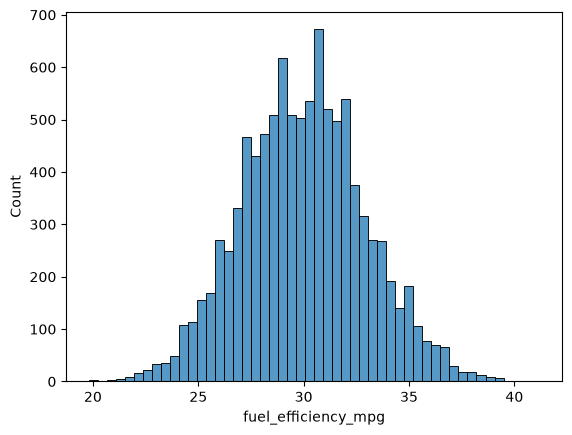

In [326]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

In [327]:
# No long tail

## 1. There's one column with missing values. What is it?
df.isnull().sum()

## 2. What's the median (50% percentile) for variable 'horsepower'?

In [328]:
median_hp = df["horsepower"].median()
median_hp

np.float64(254.0)

In [329]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
df_train.reset_index(drop=True)
df_val.reset_index(drop=True)
df_test.reset_index(drop=True)

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
0,1981,2370,268.0,4410,27.8
1,2020,2240,256.0,4220,37.3
2,2023,2090,217.0,3910,33.1
3,2021,2280,251.0,4420,31.3
4,1979,2450,256.0,4420,26.4
...,...,...,...,...,...
1995,1988,2100,257.0,4130,30.7
1996,2000,2160,231.0,4180,25.5
1997,2013,2430,246.0,4660,30.1
1998,2014,2450,307.0,4500,30.5


In [330]:
## Question 3
## We need to deal with missing values for the column from Q1.
## We have two options: fill it with 0 or with the mean of this variable.
## Try both options. For each, train a linear regression model without regularization using the code from the lessons.
## For computing the mean, use the training only!
## Use the validation dataset to evaluate the models and compare the RMSE of each option.
## Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
## Which option gives better RMSE?

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values

X_train = df_train.drop(columns='fuel_efficiency_mpg')
X_val = df_val.drop(columns='fuel_efficiency_mpg')

def train_linear_regression(X, y):
    # adding the dummy column
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    # normal equation formula
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

## horsepower = 0
X_train_0 = X_train.copy()
X_val_0 = X_val.copy()

X_train_0['horsepower'] = X_train_0['horsepower'].fillna(0)
X_val_0['horsepower'] = X_val_0['horsepower'].fillna(0)

w0_zero, w_zero = train_linear_regression(X_train_0.values, y_train)
y_pred_zero = w0_zero + X_val_0.values.dot(w_zero)
rmse_zero = rmse(y_val, y_pred_zero)
rmse_zero_rounded = round(rmse_zero, 3)
rmse_zero_rounded

## horsepower = mean
hp_mean = X_train['horsepower'].mean()
X_train_mean = X_train.copy()
X_val_mean = X_val.copy()

X_train_mean['horsepower'] = X_train_mean['horsepower'].fillna(hp_mean)
X_val_mean['horsepower'] = X_val_mean['horsepower'].fillna(hp_mean)

w0_mean, w_mean = train_linear_regression(X_train_mean.values, y_train)
y_pred_mean = w0_mean + X_val_mean.values.dot(w_mean)

rmse_mean = rmse(y_val, y_pred_mean)
rmse_mean_rounded = round(rmse_mean, 3)

if rmse_zero_rounded < rmse_mean_rounded:
    print ("With 0")
elif rmse_zero_rounded > rmse_mean_rounded:
    print("With mean")
else:
    print("Both are equal")


With mean


In [331]:
## Question 4
# Now let's train a regularized linear regression.
# For this question, fill the NAs with 0.
# Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
# Use RMSE to evaluate the model on the validation dataset.
# Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
# Which r gives the best RMSE?

def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    reg[0, 0] = 0 
    XTX = XTX + reg
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

X_train_q4 = df_train.drop(columns='fuel_efficiency_mpg').copy()
X_val_q4 = df_val.drop(columns='fuel_efficiency_mpg').copy()
y_train_q4 = df_train['fuel_efficiency_mpg'].values
y_val_q4 = df_val['fuel_efficiency_mpg'].values

X_train_q4['horsepower'] = X_train_q4['horsepower'].fillna(0)
X_val_q4['horsepower'] = X_val_q4['horsepower'].fillna(0)

r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
results = []

for r in r_values:
    w0, w = train_linear_regression_reg(X_train_q4.values, y_train_q4, r=r)
    y_pred = w0 + X_val_q4.values.dot(w)
    
    score = rmse(y_val_q4, y_pred)
    score_rounded = round(score, 4)
    
    results.append((r, score_rounded))

results.sort(key=lambda x: (x[1], x[0]))
best_r = results[0][0]
best_r


0

In [332]:
## Question 5
# We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
# Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
# For each seed, do the train/validation/test split with 60%/20%/20% distribution.
# Fill the missing values with 0 and train a model without regularization.
# For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
# What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
# Round the result to 3 decimal digits (round(std, 3))

seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scores = []
for s in seeds:
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values

    X_train = df_train.drop(columns='fuel_efficiency_mpg').copy()
    X_val = df_val.drop(columns='fuel_efficiency_mpg').copy()

    X_train['horsepower'] = X_train['horsepower'].fillna(0)
    X_val['horsepower'] = X_val['horsepower'].fillna(0)

    w0, w = train_linear_regression(X_train.values, y_train)

    y_pred = w0 + X_val.values.dot(w)
    score = rmse(y_val, y_pred)
    
    rmse_scores.append(score)
    print(f"Seed {s}: RMSE = {score:.4f}")

std_scores = np.std(rmse_scores)
std_rounded = round(std_scores, 3)

std_rounded

Seed 0: RMSE = 2.2392
Seed 1: RMSE = 2.2021
Seed 2: RMSE = 2.1634
Seed 3: RMSE = 2.2044
Seed 4: RMSE = 2.2019
Seed 5: RMSE = 2.2458
Seed 6: RMSE = 2.2697
Seed 7: RMSE = 2.1908
Seed 8: RMSE = 2.2166
Seed 9: RMSE = 2.2070


np.float64(0.029)

In [334]:
## Split the dataset like previously, use seed 9.
# Combine train and validation datasets.
# Fill the missing values with 0 and train a model with r=0.001.
# What's the RMSE on the test dataset?

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_train_full = pd.concat([df_train, df_val])
df_train_full = df_train_full.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train_full = df_train_full['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

X_train_full = df_train_full.drop(columns='fuel_efficiency_mpg').copy()
X_test = df_test.drop(columns='fuel_efficiency_mpg').copy()

# 4. Umplem valorile lipsă cu 0
X_train_full['horsepower'] = X_train_full['horsepower'].fillna(0)
X_test['horsepower'] = X_test['horsepower'].fillna(0)

r = 0.001
w0, w = train_linear_regression_reg(X_train_full.values, y_train_full, r=r)

y_pred_test = w0 + X_test.values.dot(w)
rmse_test = rmse(y_test, y_pred_test)
rmse_test_rounded = round(rmse_test, 3)
rmse_test_rounded

np.float64(2.236)